In [20]:
import pandas as pd
import importlib
import PortfolioBacktester.modules.data_wrangling as dw
from PortfolioBacktester.entinties import NaiveBacktest
import matplotlib.pyplot as plt


In [21]:
"""
INPUT PARAMETERS
"""

portfolio_path = "Input/weights_portfolio"
investable_universe_path = "Input/investable_assets"



In [22]:
"""
LOAD DATA
"""

portfolio_weights = dw.load_csv(portfolio_path, "test_weights_df")
portfolio_weights.columns = pd.to_datetime(portfolio_weights.columns, format="%d/%m/%Y")
start_date = portfolio_weights.columns[0]
end_date = portfolio_weights.columns[-1]
investable_assets = portfolio_weights.index

portfolio_weights


,2017-06-08,2017-09-11,2018-01-31,2018-02-08,2018-02-09,2018-02-12,2018-03-29,2018-04-09,2018-04-16,2018-04-18,...,2025-03-26,2025-04-03,2025-04-04,2025-04-07,2025-04-09,2025-04-10,2025-05-05,2025-05-14,2025-05-15,2025-05-16
m_date,,,,,,,,,,,,,,,,,,,,,
XLRE,0,0,0,0.5,0.333333,0.25,0.2,0.166667,0.142857,0.166667,...,0.25,0.333333,0.25,0.166667,0.125,0.111111,0.1,0.111111,0.125,0.142857
XLU,0,0,1,0.5,0.333333,0.25,0.2,0.166667,0.142857,0.000000,...,0.00,0.000000,0.00,0.000000,0.000,0.000000,0.1,0.000000,0.000,0.000000
XLK,0,0,0,0.0,0.000000,0.00,0.0,0.000000,0.000000,0.000000,...,0.25,0.333333,0.25,0.166667,0.125,0.111111,0.1,0.111111,0.125,0.000000
XLB,0,0,0,0.0,0.000000,0.00,0.0,0.166667,0.142857,0.166667,...,0.00,0.000000,0.25,0.166667,0.125,0.111111,0.1,0.111111,0.125,0.142857
XLI,0,0,0,0.0,0.000000,0.00,0.0,0.000000,0.142857,0.166667,...,0.00,0.000000,0.00,0.166667,0.125,0.111111,0.1,0.111111,0.125,0.142857
XLV,0,0,0,0.0,0.000000,0.25,0.2,0.166667,0.142857,0.166667,...,0.00,0.000000,0.00,0.000000,0.125,0.111111,0.1,0.111111,0.125,0.142857
XLF,0,0,0,0.0,0.000000,0.00,0.0,0.000000,0.000000,0.000000,...,0.00,0.000000,0.00,0.000000,0.000,0.111111,0.1,0.111111,0.000,0.000000
XLE,1,1,0,0.0,0.000000,0.00,0.2,0.166667,0.142857,0.166667,...,0.00,0.000000,0.00,0.000000,0.125,0.111111,0.1,0.111111,0.125,0.142857
XLP,0,0,0,0.0,0.333333,0.25,0.2,0.166667,0.142857,0.166667,...,0.25,0.000000,0.00,0.166667,0.125,0.111111,0.1,0.111111,0.125,0.142857


In [23]:
"""
BUILD DFS
"""

series_list = [dw.column_df(investable_universe_path, name, "m_adjusted_close") for name in investable_assets]
asset_prices = pd.concat(series_list, axis=1)
asset_prices.index = pd.to_datetime(asset_prices.index)
asset_prices.sort_index(inplace=True)

asset_prices


,XLRE,XLU,XLK,XLB,XLI,XLV,XLF,XLE,XLP,XLY
m_date,,,,,,,,,,
2001-12-31,NaN,12.38,17.96,12.910,17.950,18.560,13.320,14.27,14.32,21.72
2002-01-02,NaN,12.56,18.41,13.010,17.950,18.720,13.300,14.17,14.27,21.79
2002-01-03,NaN,12.63,19.22,13.250,17.950,18.800,13.390,14.08,14.23,21.72
2002-01-04,NaN,12.57,19.34,13.500,17.950,19.020,13.570,14.14,14.19,22.08
2002-01-07,NaN,12.58,19.13,13.500,17.830,19.050,13.530,14.14,14.08,21.95
...,...,...,...,...,...,...,...,...,...,...
2025-05-22,40.630,80.10,229.34,85.870,141.290,130.550,50.230,81.73,81.30,212.56
2025-05-23,40.640,81.06,226.81,85.700,140.830,130.340,50.050,81.99,81.60,210.65
2025-05-27,41.310,81.67,232.20,87.200,143.310,132.160,50.930,82.70,82.34,216.87


In [24]:
crossvalidated_dates = (
    # ('2017-01-01', '2017-12-31'),
    # ('2018-01-01', '2018-12-31'),
    # ('2019-01-01', '2019-12-31'),
    # ('2020-01-01', '2020-12-31'),
    # ('2021-01-01', '2021-12-31'),
    # ('2022-01-01', '2022-12-31'),
    # ('2023-01-01', '2023-12-31'),
    # ('2024-01-01', '2024-12-31'),
    # ('2025-01-01', '2025-12-31'),
    ('2017-01-01', '2025-12-31'),  # Full period for final backtest
)


NaiveBacktest(start_date=2017-01-01, end_date=2025-12-31), investable_assets=['XLRE', 'XLU', 'XLK', 'XLB', 'XLI', 'XLV', 'XLF', 'XLE', 'XLP', 'XLY'], 


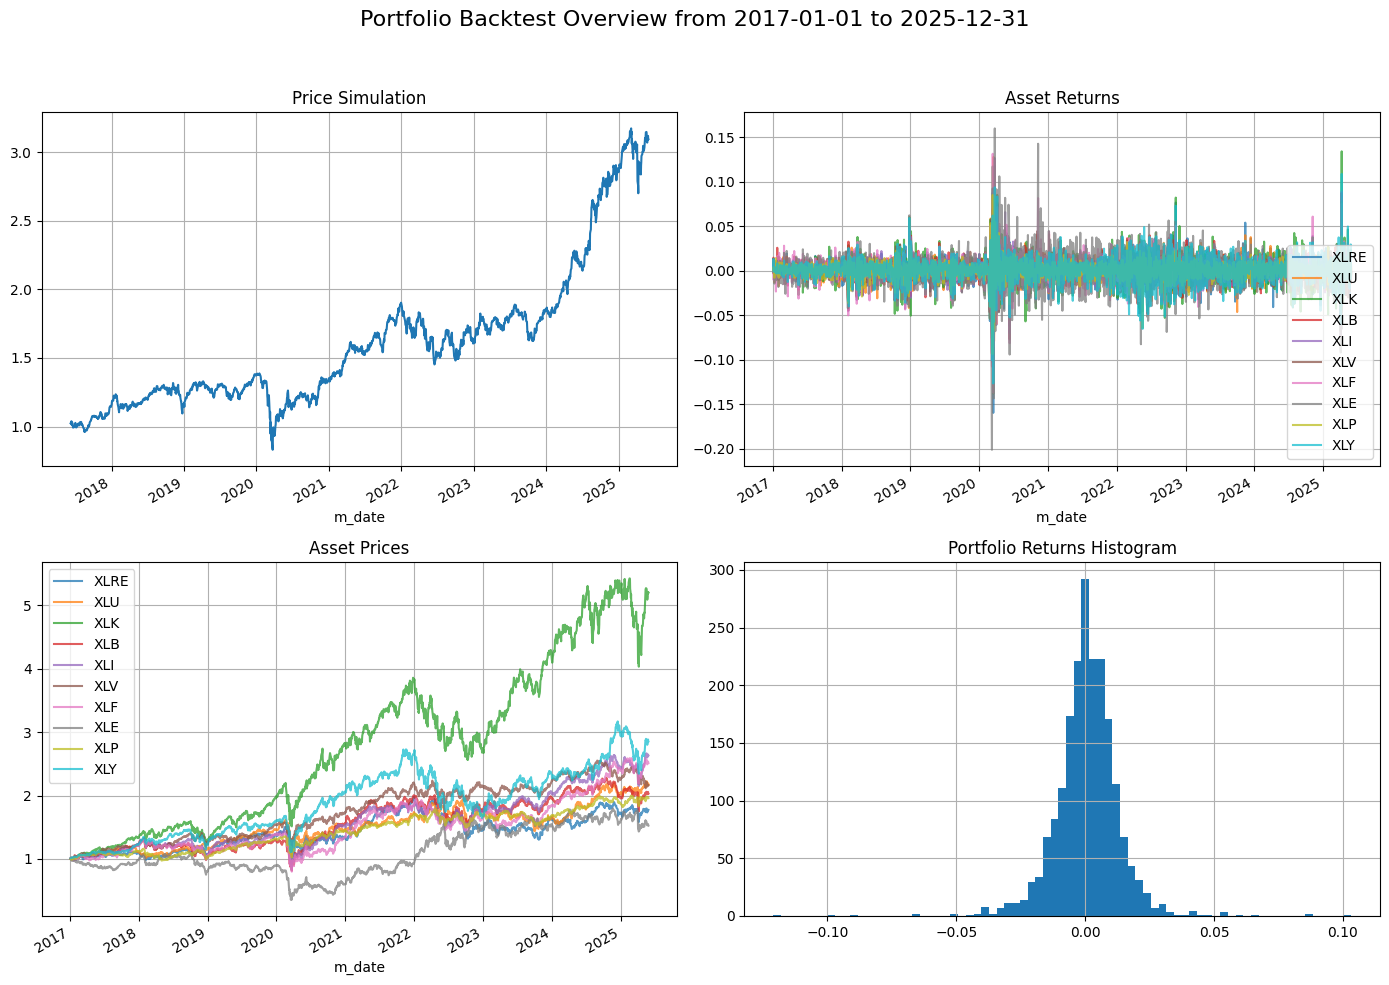

In [25]:
performance_metrics = []
for start_date, end_date in crossvalidated_dates:
    portfolio_backtest = NaiveBacktest(
        start_date=start_date,
        end_date=end_date,
        signals_df=portfolio_weights,
        asset_prices=asset_prices,
        initial_capital=1
    )
    print(portfolio_backtest)

    portfolio_backtest._run_backtest()

    portfolio_backtest.performance_plots()

    metrics_i = portfolio_backtest.performance_metrics()
    performance_metrics.append(metrics_i)

cv_metrics = pd.concat(performance_metrics)


In [26]:
cv_metrics

,Annualized Return,Annualized Vol,Sharpe Ratio,Max Drawdown,Skewness,Kurtosis,Cornish-Fisher VaR (5%),Historic CVaR (5%)
Strategy,0.152605,0.205301,0.743324,-0.40111,-0.371337,15.182024,0.018772,0.02981


In [27]:
backtested_daily_weights = portfolio_backtest.backtested_daily_weights

backtested_daily_weights

,XLRE,XLU,XLK,XLB,XLI,XLV,XLF,XLE,XLP,XLY
m_date,,,,,,,,,,
2017-06-08,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,1.000000,0.000000,0.000000
2017-06-09,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,1.024070,0.000000,0.000000
2017-06-12,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,1.031291,0.000000,0.000000
2017-06-13,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,1.038950,0.000000,0.000000
2017-06-14,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.0,1.020131,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...
2025-05-22,0.138164,0.0,0.0,0.140921,0.140383,0.140131,0.0,0.136590,0.141517,0.139503
2025-05-23,0.138198,0.0,0.0,0.140642,0.139926,0.139905,0.0,0.137025,0.142039,0.138250
2025-05-27,0.140477,0.0,0.0,0.143103,0.142390,0.141859,0.0,0.138211,0.143327,0.142332


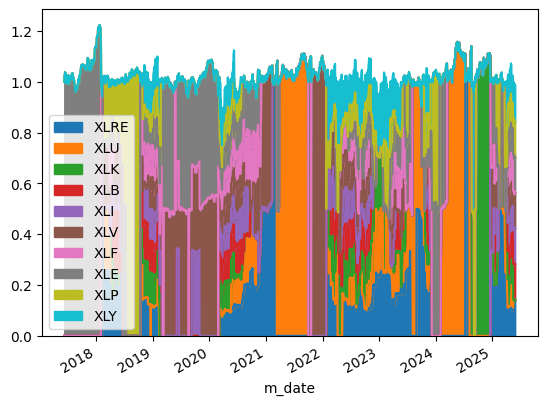

In [28]:
backtested_daily_weights.plot.area()

plt.show()

In [29]:
backtested_daily_weights.sum(axis = 1)

m_date
2017-06-08    1.000000
2017-06-09    1.024070
2017-06-12    1.031291
2017-06-13    1.038950
2017-06-14    1.020131
                ...   
2025-05-22    0.977209
2025-05-23    0.975985
2025-05-27    0.991699
2025-05-28    0.984276
2025-05-29    0.983818
Length: 2005, dtype: float64

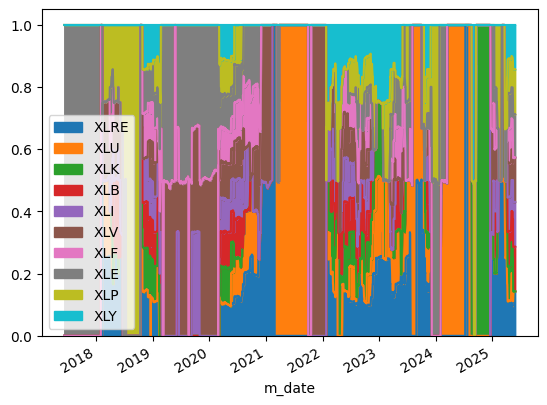

In [30]:
normalized_weights = backtested_daily_weights.div(backtested_daily_weights.sum(axis = 1), axis = 0)

normalized_weights.plot.area()
plt.show()